# Notebook 2: Data Processing & EDA — Bronze to Silver Layer
## Proyek Analisis Performa Kampanye Marketing

**Penanggung Jawab:** Naufal Zahdan Zulfakar (Data Engineer 2 - Spark Processing)

### Medallion Architecture — Silver Layer
- Input: `bronze/marketing_campaign_performance.csv`
- Output: `silver/marketing_campaign_cleaned` dan `silver/marketing_campaign_features`

---
## Step 1: Setup Environment & Spark Session

In [1]:
import os, sys, warnings, glob as _glob
warnings.filterwarnings('ignore')

# ============================================================
# FIX Windows: Set environment variables sebelum import PySpark
# ============================================================
os.environ["JAVA_HOME"]   = r"C:\Program Files\Java\jdk-21.0.10"
os.environ["SPARK_HOME"]  = r"C:\spark\spark-4.1.1-bin-hadoop3"
os.environ["HADOOP_HOME"] = r"C:\Users\muham\OneDrive\Dokumen\Dokumen\BigData\bigdata6-marketing-analytics\hadoop"
_py4j = _glob.glob(os.path.join(os.environ["SPARK_HOME"], "python", "lib", "py4j-*.zip"))
sys.path.insert(0, os.path.join(os.environ["SPARK_HOME"], "python"))
if _py4j: sys.path.insert(0, _py4j[0])
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

print("[OK] Library berhasil di-import!")
print(f"   JAVA_HOME   : {os.environ['JAVA_HOME']}")
print(f"   SPARK_HOME  : {os.environ['SPARK_HOME']}")
print(f"   HADOOP_HOME : {os.environ['HADOOP_HOME']}")

[OK] Library berhasil di-import!
   JAVA_HOME   : C:\Program Files\Java\jdk-21.0.10
   SPARK_HOME  : C:\spark\spark-4.1.1-bin-hadoop3
   HADOOP_HOME : C:\Users\muham\OneDrive\Dokumen\Dokumen\BigData\bigdata6-marketing-analytics\hadoop


In [2]:
# Konfigurasi MinIO
MINIO_ENDPOINT = "localhost:9000"
MINIO_ACCESS_KEY = "minioadmin"
MINIO_SECRET_KEY = "minioadmin123"
MINIO_BUCKET = "marketing-data"

BRONZE_CSV_PATH      = f"s3a://{MINIO_BUCKET}/bronze/marketing_campaign_performance.csv"
SILVER_CLEANED_PATH  = f"s3a://{MINIO_BUCKET}/silver/marketing_campaign_cleaned"
SILVER_FEATURES_PATH = f"s3a://{MINIO_BUCKET}/silver/marketing_campaign_features"

# hadoop-aws-3.3.1.jar & aws-java-sdk-bundle-1.11.901.jar
# sudah ada di C:/spark/spark-4.1.1-bin-hadoop3/jars/
#
# Override wajib: Hadoop 3.4.2 (bundled Spark 4.x) punya default config
# format duration string (60s, 200s, dll) yang tidak kompatibel dengan
# S3AFileSystem.initThreadPools() yang menggunakan getLong().
spark = SparkSession.builder \
    .appName("Marketing_Campaign_Processing_EDA") \
    .master("local[*]") \
    .config("spark.hadoop.fs.s3a.endpoint", f"http://{MINIO_ENDPOINT}") \
    .config("spark.hadoop.fs.s3a.access.key", MINIO_ACCESS_KEY) \
    .config("spark.hadoop.fs.s3a.secret.key", MINIO_SECRET_KEY) \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.threads.keepalivetime", "60") \
    .config("spark.hadoop.fs.s3a.connection.timeout", "200000") \
    .config("spark.hadoop.fs.s3a.connection.establish.timeout", "30000") \
    .config("spark.hadoop.fs.s3a.connection.ttl", "300000") \
    .config("spark.hadoop.fs.s3a.multipart.purge.age", "86400") \
    .config("spark.hadoop.fs.s3a.assumed.role.session.duration", "1800") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f'[OK] SparkSession dibuat! Versi: {spark.version}')

[OK] SparkSession dibuat! Versi: 4.1.1


---
## Step 2: Load Data dari MinIO (Bronze Layer)

In [3]:
df_raw = spark.read.csv(BRONZE_CSV_PATH, header=True, inferSchema=True)

print(f'[OK] Data berhasil dimuat dari Bronze Layer!')
print(f'   Jumlah Record : {df_raw.count():,}')
print(f'   Jumlah Kolom  : {len(df_raw.columns)}')
df_raw.printSchema()

[OK] Data berhasil dimuat dari Bronze Layer!
   Jumlah Record : 10,000
   Jumlah Kolom  : 11
root
 |-- CampaignID: string (nullable = true)
 |-- StartDate: date (nullable = true)
 |-- EndDate: date (nullable = true)
 |-- Channel: string (nullable = true)
 |-- Impressions: integer (nullable = true)
 |-- Clicks: integer (nullable = true)
 |-- Leads: integer (nullable = true)
 |-- Conversions: integer (nullable = true)
 |-- Cost_USD: double (nullable = true)
 |-- Revenue_USD: double (nullable = true)
 |-- ROI: double (nullable = true)



In [4]:
df_raw.show(5, truncate=False)

+----------+----------+----------+----------+-----------+------+-----+-----------+--------+-----------+----+
|CampaignID|StartDate |EndDate   |Channel   |Impressions|Clicks|Leads|Conversions|Cost_USD|Revenue_USD|ROI |
+----------+----------+----------+----------+-----------+------+-----+-----------+--------+-----------+----+
|CAMP00001 |2025-04-13|2025-04-19|Search    |293520     |23335 |11643|5389       |1052.39 |2236.02    |1.12|
|CAMP00002 |2025-12-15|2025-12-24|Search    |200340     |15841 |6601 |2498       |3964.9  |11740.15   |1.96|
|CAMP00003 |2025-09-28|2025-10-06|Email     |239365     |16478 |8043 |3397       |1000.39 |1902.24    |0.9 |
|CAMP00004 |2025-04-17|2025-04-30|Search    |156382     |2672  |1014 |342        |1252.63 |2209.74    |0.76|
|CAMP00005 |2025-03-13|2025-03-22|Influencer|285472     |4155  |1521 |565        |4935.48 |14111.31   |1.86|
+----------+----------+----------+----------+-----------+------+-----+-----------+--------+-----------+----+
only showing top 5 

---
## Step 3: EDA
### 3.1 Statistik Deskriptif

In [5]:
df_raw.describe().toPandas()

,summary,CampaignID,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,count,10000,10000,10000,10000,10000,10000,10000,10000,10000
1,mean,NaN,NaN,152260.6379,8338.9933,2512.4636,1010.7,2552.3569909999974,5102.648929999979,1.0015760000000025
2,stddev,NaN,NaN,85251.70762050127,6546.326431032073,2321.031302439879,1019.40261269465,1427.694544774451,3309.3267049072447,0.5788056649893651
3,min,CAMP00001,Display,5043,72,10,4,100.23,113.64,0.0
4,max,CAMP10000,Social,299997,29578,13833,7987,4998.42,14871.34,2.0


In [6]:
print('Statistik per Channel:')
df_raw.groupBy('Channel').agg(
    F.count('*').alias('Jumlah_Kampanye'),
    F.round(F.avg('ROI'), 3).alias('Avg_ROI'),
    F.round(F.avg('Revenue_USD'), 2).alias('Avg_Revenue'),
    F.round(F.avg('Cost_USD'), 2).alias('Avg_Cost'),
    F.round(F.avg('Conversions'), 1).alias('Avg_Conversions'),
    F.round(F.sum('Revenue_USD'), 2).alias('Total_Revenue')
).orderBy('Avg_ROI', ascending=False).show()

Statistik per Channel:
+----------+---------------+-------+-----------+--------+---------------+-------------+
|   Channel|Jumlah_Kampanye|Avg_ROI|Avg_Revenue|Avg_Cost|Avg_Conversions|Total_Revenue|
+----------+---------------+-------+-----------+--------+---------------+-------------+
|    Search|           1924|  1.013|    5144.32| 2555.39|         1014.4|   9897677.79|
|     Email|           1996|   1.01|    5075.42| 2537.59|         1040.3|1.013054261E7|
|   Display|           2069|  0.999|    5178.89|  2582.5|          994.5|1.071512521E7|
|Influencer|           2056|  0.998|    5135.27|  2567.5|         1022.0|1.055811899E7|
|    Social|           1955|  0.988|    4974.44| 2516.62|          982.1|    9725024.7|
+----------+---------------+-------+-----------+--------+---------------+-------------+



### 3.2 Visualisasi Distribusi

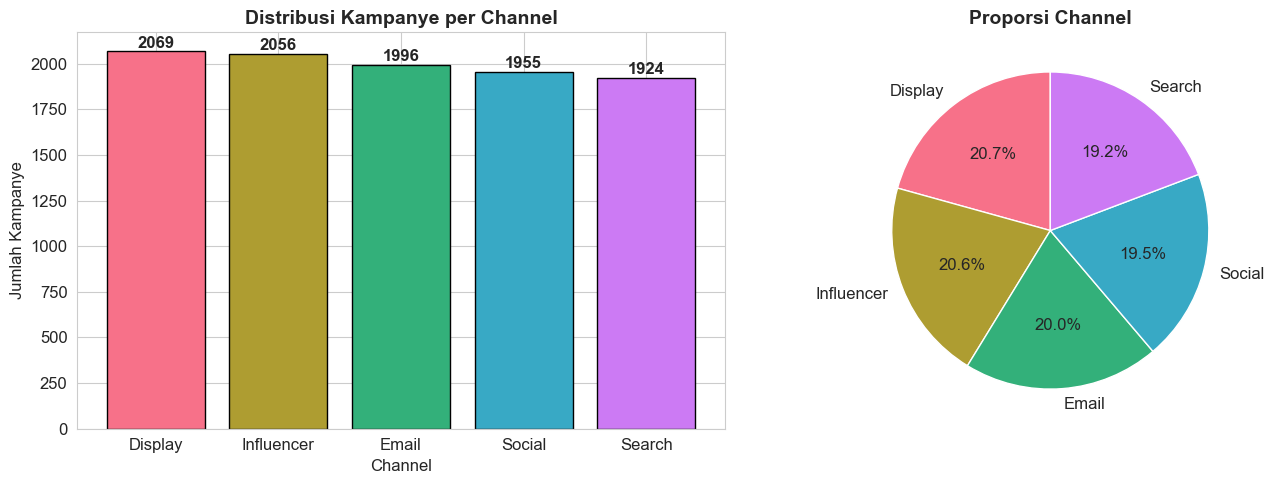

In [7]:
pdf = df_raw.toPandas()
colors = sns.color_palette('husl', 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
channel_counts = pdf['Channel'].value_counts()
axes[0].bar(channel_counts.index, channel_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Kampanye per Channel', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Jumlah Kampanye')
for i, v in enumerate(channel_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(channel_counts.values, labels=channel_counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90)
axes[1].set_title('Proporsi Channel', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

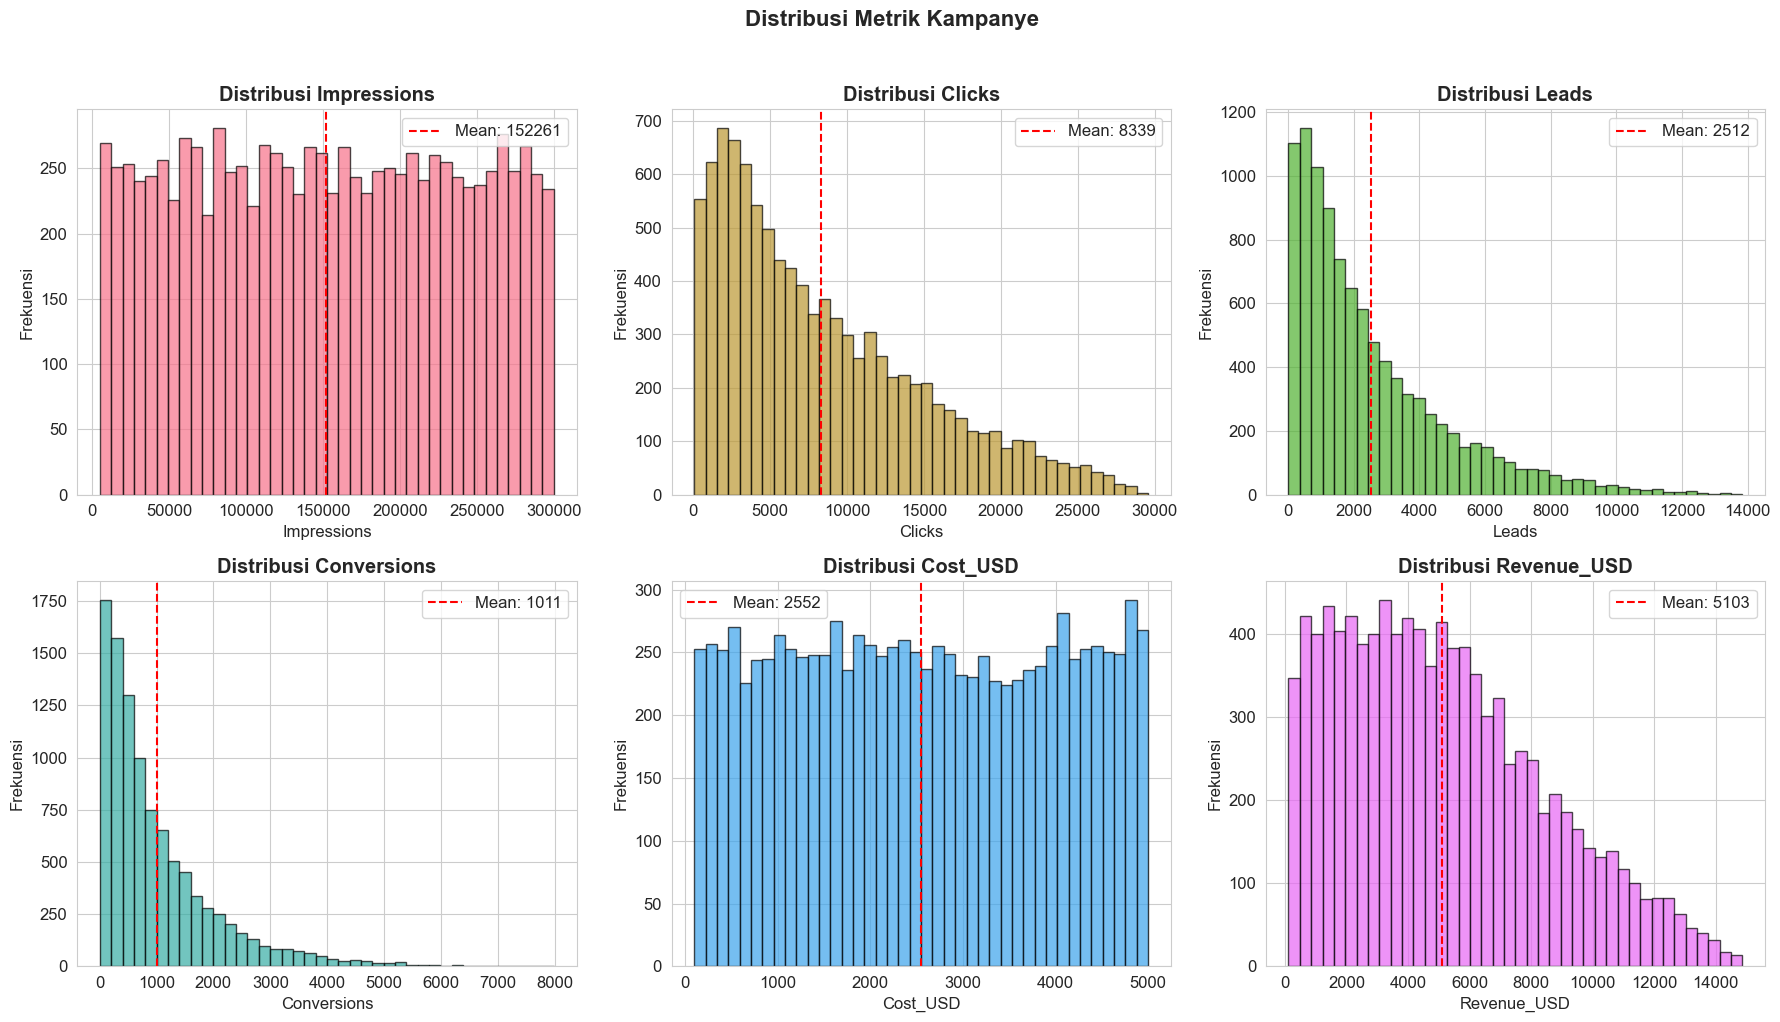

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Impressions', 'Clicks', 'Leads', 'Conversions', 'Cost_USD', 'Revenue_USD']
colors2 = sns.color_palette('husl', 6)

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3][idx % 3]
    ax.hist(pdf[metric], bins=40, color=colors2[idx], edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribusi {metric}', fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_ylabel('Frekuensi')
    ax.axvline(pdf[metric].mean(), color='red', linestyle='--',
               label=f'Mean: {pdf[metric].mean():.0f}')
    ax.legend()

plt.suptitle('Distribusi Metrik Kampanye', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

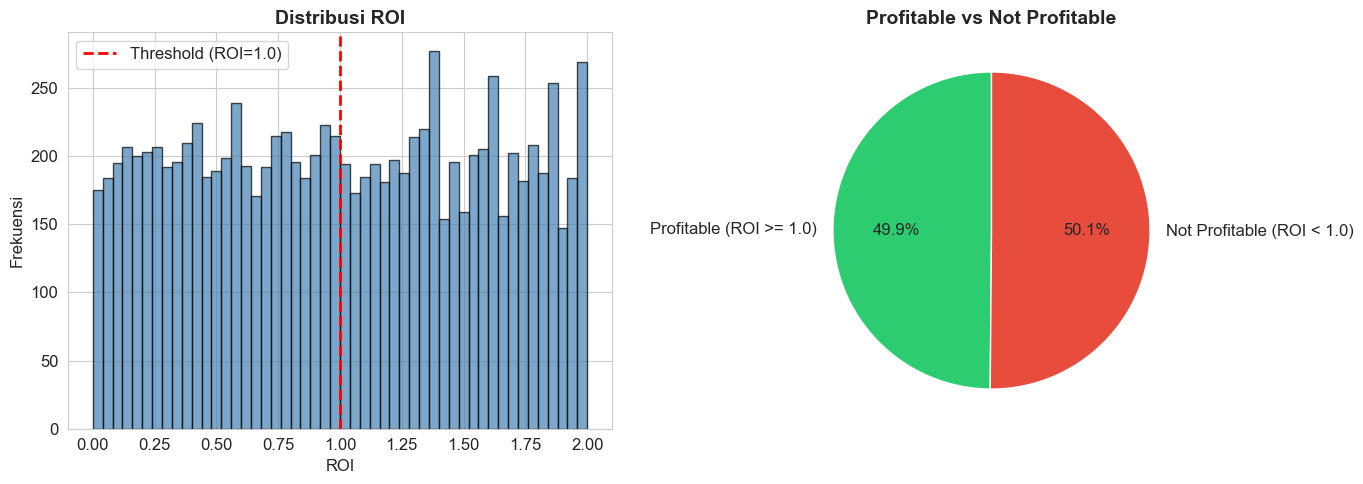

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pdf['ROI'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Threshold (ROI=1.0)')
axes[0].set_title('Distribusi ROI', fontweight='bold', fontsize=14)
axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

labels = ['Profitable (ROI >= 1.0)', 'Not Profitable (ROI < 1.0)']
sizes = [(pdf['ROI'] >= 1.0).sum(), (pdf['ROI'] < 1.0).sum()]
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%',
           colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Profitable vs Not Profitable', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

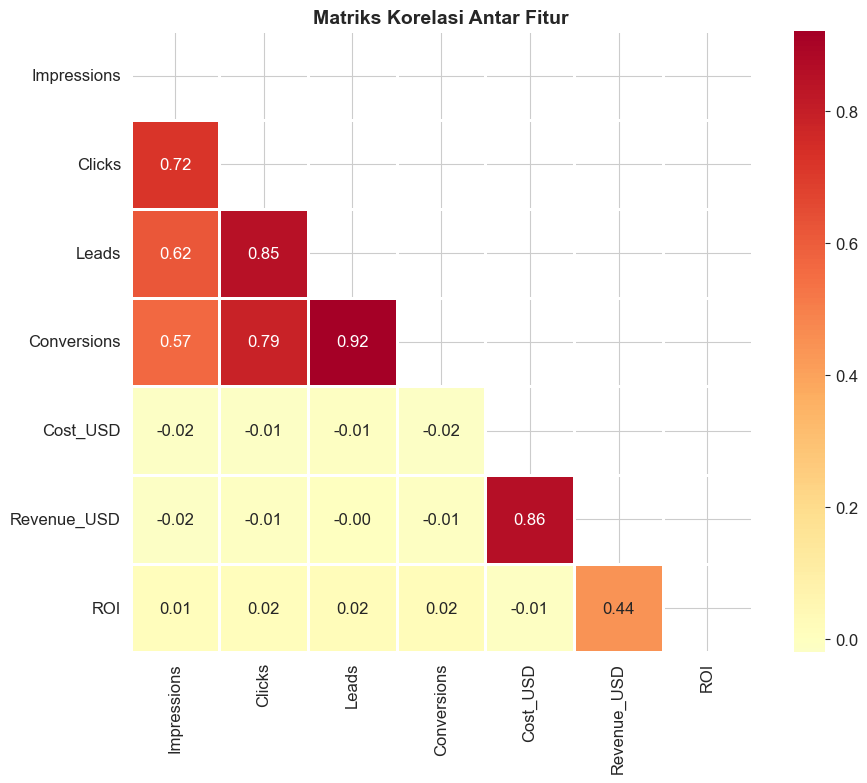

In [10]:
numeric_cols = ['Impressions', 'Clicks', 'Leads', 'Conversions', 'Cost_USD', 'Revenue_USD', 'ROI']
corr_matrix = pdf[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Matriks Korelasi Antar Fitur', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

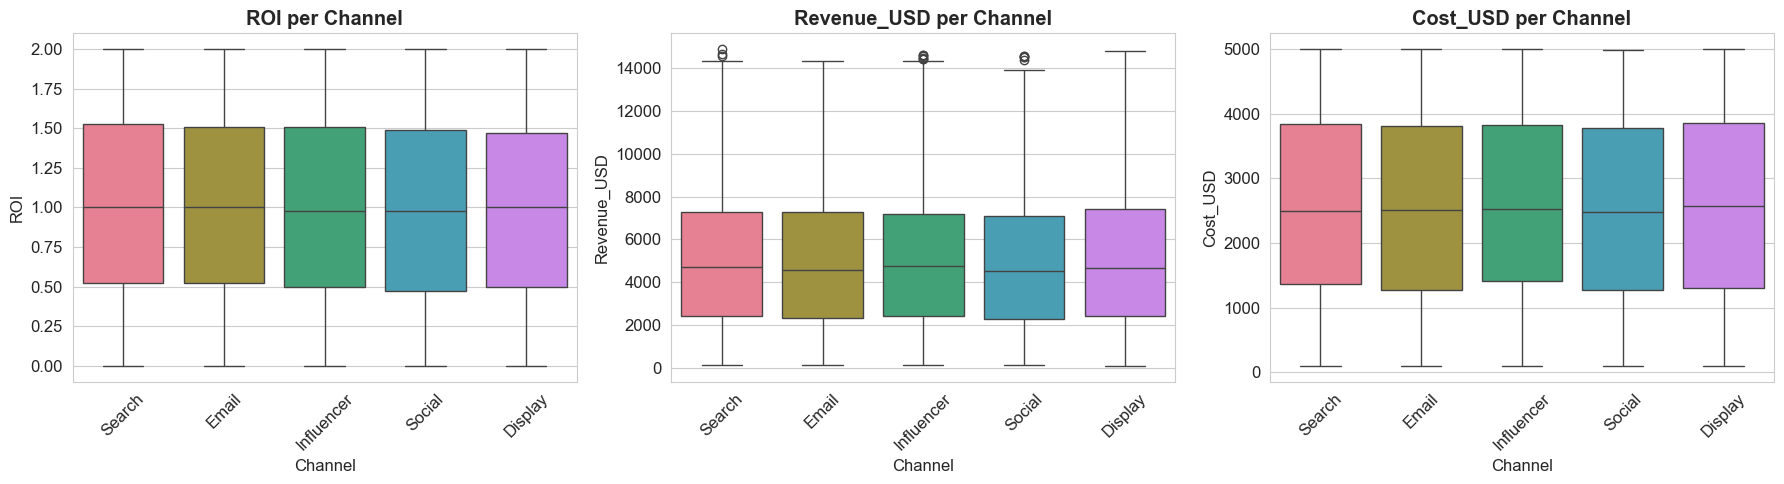

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, metric in enumerate(['ROI', 'Revenue_USD', 'Cost_USD']):
    sns.boxplot(data=pdf, x='Channel', y=metric, ax=axes[idx], palette='husl')
    axes[idx].set_title(f'{metric} per Channel', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Step 4: Data Cleaning

In [12]:
print('Pengecekan Missing Values:')
total_rows = df_raw.count()
for col_name in df_raw.columns:
    null_count = df_raw.filter(F.col(col_name).isNull()).count()
    pct = null_count / total_rows * 100
    status = '[OK]' if null_count == 0 else '[WARN]'
    print(f'   {status} {col_name:<15s}: {null_count:>5d} null ({pct:.2f}%)')

df_clean = df_raw.dropna()
dropped = total_rows - df_clean.count()
print(f'\nBaris dihapus karena null: {dropped}')

Pengecekan Missing Values:
   [OK] CampaignID     :     0 null (0.00%)
   [OK] StartDate      :     0 null (0.00%)
   [OK] EndDate        :     0 null (0.00%)
   [OK] Channel        :     0 null (0.00%)
   [OK] Impressions    :     0 null (0.00%)
   [OK] Clicks         :     0 null (0.00%)
   [OK] Leads          :     0 null (0.00%)
   [OK] Conversions    :     0 null (0.00%)
   [OK] Cost_USD       :     0 null (0.00%)
   [OK] Revenue_USD    :     0 null (0.00%)
   [OK] ROI            :     0 null (0.00%)

Baris dihapus karena null: 0


In [13]:
total = df_clean.count()
distinct = df_clean.select('CampaignID').distinct().count()
duplicates = total - distinct
print(f'Total record    : {total:,}')
print(f'CampaignID unik : {distinct:,}')
print(f'Duplikasi       : {duplicates}')

if duplicates > 0:
    df_clean = df_clean.dropDuplicates(['CampaignID'])
    print(f'[OK] {duplicates} duplikasi dihapus')
else:
    print('[OK] Tidak ada duplikasi')

Total record    : 10,000
CampaignID unik : 10,000
Duplikasi       : 0
[OK] Tidak ada duplikasi


In [14]:
df_clean = df_clean.withColumn('StartDate', F.to_date(F.col('StartDate'), 'yyyy-MM-dd'))
df_clean = df_clean.withColumn('EndDate', F.to_date(F.col('EndDate'), 'yyyy-MM-dd'))
print('[OK] Konversi tipe data selesai')
df_clean.printSchema()

[OK] Konversi tipe data selesai
root
 |-- CampaignID: string (nullable = true)
 |-- StartDate: date (nullable = true)
 |-- EndDate: date (nullable = true)
 |-- Channel: string (nullable = true)
 |-- Impressions: integer (nullable = true)
 |-- Clicks: integer (nullable = true)
 |-- Leads: integer (nullable = true)
 |-- Conversions: integer (nullable = true)
 |-- Cost_USD: double (nullable = true)
 |-- Revenue_USD: double (nullable = true)
 |-- ROI: double (nullable = true)



In [15]:
print('Deteksi Outlier (IQR Method):')
outlier_cols = ['Impressions', 'Clicks', 'Leads', 'Conversions', 'Cost_USD', 'Revenue_USD']
for col_name in outlier_cols:
    quantiles = df_clean.approxQuantile(col_name, [0.25, 0.75], 0.01)
    Q1, Q3 = quantiles[0], quantiles[1]
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = df_clean.filter(
        (F.col(col_name) < lower) | (F.col(col_name) > upper)
    ).count()
    pct = outlier_count / df_clean.count() * 100
    print(f'   {col_name:<15s}: {outlier_count:>4d} outliers ({pct:.1f}%)')

print('[INFO] Outlier dipertahankan - variasi natural kampanye marketing')

Deteksi Outlier (IQR Method):
   Impressions    :    0 outliers (0.0%)
   Clicks         :  131 outliers (1.3%)
   Leads          :  482 outliers (4.8%)
   Conversions    :  593 outliers (5.9%)
   Cost_USD       :    0 outliers (0.0%)
   Revenue_USD    :   27 outliers (0.3%)
[INFO] Outlier dipertahankan - variasi natural kampanye marketing


---
## Step 5: Feature Engineering

In [16]:
df_features = df_clean \
    .withColumn('CTR',
        F.when(F.col('Impressions') > 0, F.col('Clicks') / F.col('Impressions')).otherwise(0)) \
    .withColumn('CPC',
        F.when(F.col('Clicks') > 0, F.col('Cost_USD') / F.col('Clicks')).otherwise(0)) \
    .withColumn('CPL',
        F.when(F.col('Leads') > 0, F.col('Cost_USD') / F.col('Leads')).otherwise(0)) \
    .withColumn('CVR',
        F.when(F.col('Clicks') > 0, F.col('Conversions') / F.col('Clicks')).otherwise(0)) \
    .withColumn('Lead_Rate',
        F.when(F.col('Clicks') > 0, F.col('Leads') / F.col('Clicks')).otherwise(0)) \
    .withColumn('ROAS',
        F.when(F.col('Cost_USD') > 0, F.col('Revenue_USD') / F.col('Cost_USD')).otherwise(0)) \
    .withColumn('Profit_USD',
        F.col('Revenue_USD') - F.col('Cost_USD')) \
    .withColumn('Campaign_Duration',
        F.datediff(F.col('EndDate'), F.col('StartDate'))) \
    .withColumn('Start_Month',
        F.month(F.col('StartDate'))) \
    .withColumn('Start_DayOfWeek',
        F.dayofweek(F.col('StartDate'))) \
    .withColumn('is_profitable',
        F.when(F.col('ROI') >= 1.0, 1).otherwise(0))

print(f'[OK] Feature engineering selesai! Total kolom: {len(df_features.columns)}')
print(f'   Kolom baru ditambahkan: Lead_Rate, ROAS, Profit_USD, Start_Month, Start_DayOfWeek')

# Cek distribusi target
print('\n--- Distribusi Label is_profitable ---')
total = df_features.count()
df_features.groupBy('is_profitable').count().orderBy('is_profitable').show()
df_features.select('CTR','CPC','CPL','CVR','ROAS','Profit_USD','Campaign_Duration','is_profitable').describe().show()

[OK] Feature engineering selesai! Total kolom: 22
   Kolom baru ditambahkan: Lead_Rate, ROAS, Profit_USD, Start_Month, Start_DayOfWeek

--- Distribusi Label is_profitable ---
+-------------+-----+
|is_profitable|count|
+-------------+-----+
|            0| 5013|
|            1| 4987|
+-------------+-----+

+-------+--------------------+--------------------+--------------------+-------------------+------------------+------------------+------------------+-----------------+
|summary|                 CTR|                 CPC|                 CPL|                CVR|              ROAS|        Profit_USD| Campaign_Duration|    is_profitable|
+-------+--------------------+--------------------+--------------------+-------------------+------------------+------------------+------------------+-----------------+
|  count|               10000|               10000|               10000|              10000|             10000|             10000|             10000|            10000|
|   mean| 0.05462188

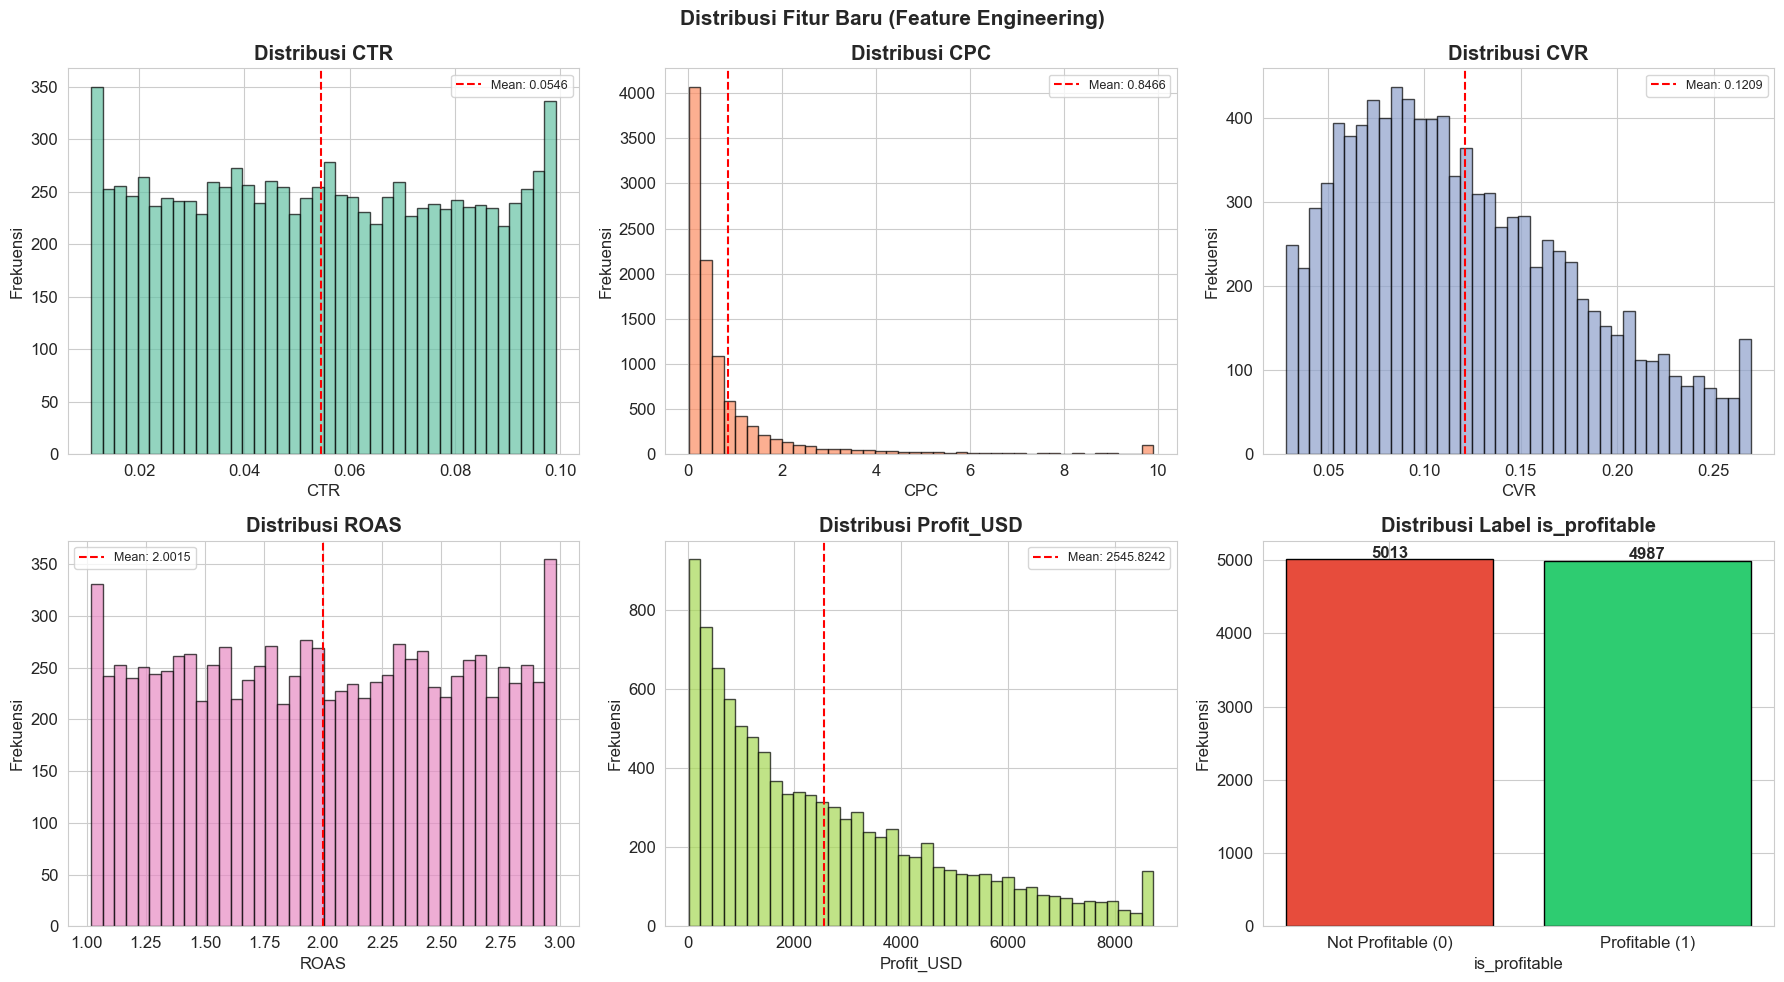

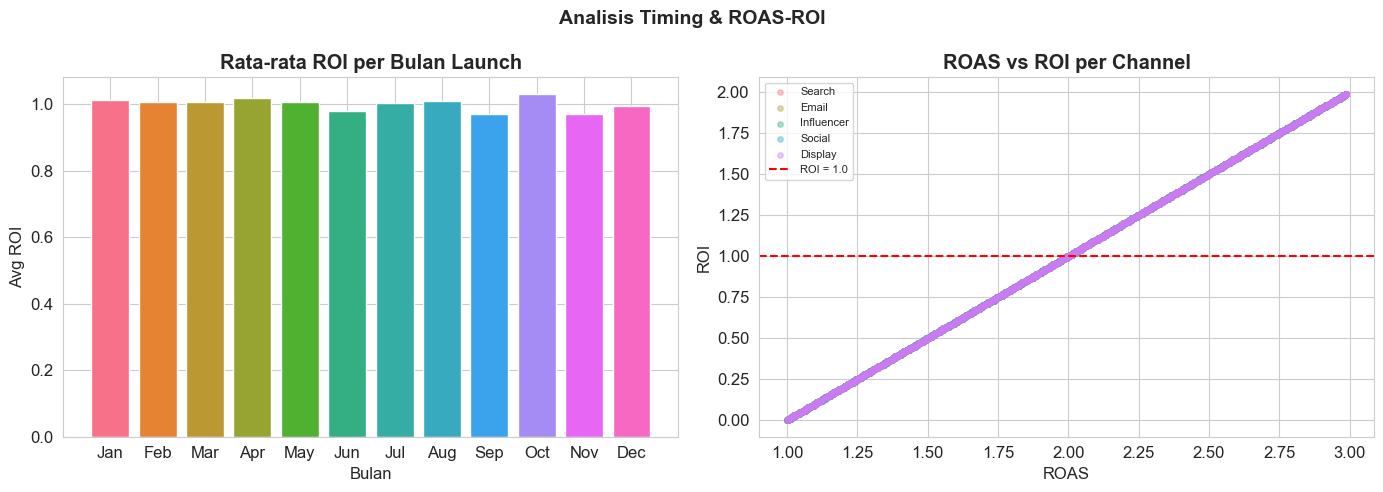

[OK] Bulan terbaik (Avg ROI tertinggi): Oct


In [17]:
pdf_feat = df_features.toPandas()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
new_features = ['CTR', 'CPC', 'CVR', 'ROAS', 'Profit_USD', 'is_profitable']
colors_feat = sns.color_palette('Set2', 6)

for idx, feat in enumerate(new_features):
    ax = axes[idx // 3][idx % 3]
    if feat == 'is_profitable':
        counts = pdf_feat[feat].value_counts().sort_index()
        ax.bar(['Not Profitable (0)', 'Profitable (1)'], counts.values,
               color=['#e74c3c', '#2ecc71'], edgecolor='black')
        for i, v in enumerate(counts.values):
            ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
        ax.set_title('Distribusi Label is_profitable', fontweight='bold')
    else:
        data = pdf_feat[feat].clip(lower=pdf_feat[feat].quantile(0.01),
                                   upper=pdf_feat[feat].quantile(0.99))
        ax.hist(data, bins=40, color=colors_feat[idx], edgecolor='black', alpha=0.7)
        ax.axvline(data.mean(), color='red', linestyle='--',
                   label=f'Mean: {data.mean():.4f}')
        ax.set_title(f'Distribusi {feat}', fontweight='bold')
        ax.legend(fontsize=9)
    ax.set_xlabel(feat)
    ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Baru (Feature Engineering)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Timing Analysis: ROI by Month ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly_roi = pdf_feat.groupby('Start_Month')['ROI'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(month_names, [monthly_roi.get(i, 0) for i in range(1, 13)],
            color=sns.color_palette('husl', 12))
axes[0].set_title('Rata-rata ROI per Bulan Launch', fontweight='bold')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Avg ROI')

# ROAS vs ROI scatter by Channel
colors_ch = sns.color_palette('husl', 5)
channels = pdf_feat['Channel'].unique()
for ch, c in zip(channels, colors_ch):
    sub = pdf_feat[pdf_feat['Channel'] == ch]
    axes[1].scatter(sub['ROAS'].clip(upper=sub['ROAS'].quantile(0.99)),
                    sub['ROI'].clip(upper=sub['ROI'].quantile(0.99)),
                    alpha=0.4, label=ch, s=15, color=c)
axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='ROI = 1.0')
axes[1].set_title('ROAS vs ROI per Channel', fontweight='bold')
axes[1].set_xlabel('ROAS')
axes[1].set_ylabel('ROI')
axes[1].legend(fontsize=8)

plt.suptitle('Analisis Timing & ROAS-ROI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_month = monthly_roi.idxmax()
print(f'[OK] Bulan terbaik (Avg ROI tertinggi): {month_names[best_month-1]}')

---
## Step 6: Simpan ke MinIO (Silver Layer)

In [18]:
print('[...] Menyimpan data Silver ke MinIO...')

df_clean.write.mode('overwrite').parquet(SILVER_CLEANED_PATH)
print(f'[OK] Silver Cleaned  : {SILVER_CLEANED_PATH}')

df_features.write.mode('overwrite').parquet(SILVER_FEATURES_PATH)
print(f'[OK] Silver Features : {SILVER_FEATURES_PATH}')

[...] Menyimpan data Silver ke MinIO...
[OK] Silver Cleaned  : s3a://marketing-data/silver/marketing_campaign_cleaned
[OK] Silver Features : s3a://marketing-data/silver/marketing_campaign_features


---
## Step 7: Verifikasi

In [19]:
df_verify = spark.read.parquet(SILVER_FEATURES_PATH)
print(f'[OK] Verifikasi Silver Layer berhasil!')
print(f'   Record : {df_verify.count():,}')
print(f'   Kolom  : {len(df_verify.columns)}')
df_verify.printSchema()
df_verify.show(5)

[OK] Verifikasi Silver Layer berhasil!
   Record : 10,000
   Kolom  : 22
root
 |-- CampaignID: string (nullable = true)
 |-- StartDate: date (nullable = true)
 |-- EndDate: date (nullable = true)
 |-- Channel: string (nullable = true)
 |-- Impressions: integer (nullable = true)
 |-- Clicks: integer (nullable = true)
 |-- Leads: integer (nullable = true)
 |-- Conversions: integer (nullable = true)
 |-- Cost_USD: double (nullable = true)
 |-- Revenue_USD: double (nullable = true)
 |-- ROI: double (nullable = true)
 |-- CTR: double (nullable = true)
 |-- CPC: double (nullable = true)
 |-- CPL: double (nullable = true)
 |-- CVR: double (nullable = true)
 |-- Lead_Rate: double (nullable = true)
 |-- ROAS: double (nullable = true)
 |-- Profit_USD: double (nullable = true)
 |-- Campaign_Duration: integer (nullable = true)
 |-- Start_Month: integer (nullable = true)
 |-- Start_DayOfWeek: integer (nullable = true)
 |-- is_profitable: integer (nullable = true)

+----------+----------+----------+

In [20]:
print('=' * 60)
print('RINGKASAN: BRONZE --> SILVER')
print('=' * 60)
print(f"""
Input  (Bronze): {BRONZE_CSV_PATH}
Output (Silver):
   Cleaned  : {SILVER_CLEANED_PATH}
   Features : {SILVER_FEATURES_PATH}
   Format   : Apache Parquet

[OK] Status: SILVER LAYER SELESAI
--> Next: Notebook 03 (ML Modeling)
""")
print('=' * 60)

RINGKASAN: BRONZE --> SILVER

Input  (Bronze): s3a://marketing-data/bronze/marketing_campaign_performance.csv
Output (Silver):
   Cleaned  : s3a://marketing-data/silver/marketing_campaign_cleaned
   Features : s3a://marketing-data/silver/marketing_campaign_features
   Format   : Apache Parquet

[OK] Status: SILVER LAYER SELESAI
--> Next: Notebook 03 (ML Modeling)



In [21]:
spark.stop()
print('[OK] SparkSession dihentikan')

[OK] SparkSession dihentikan
